# Alzheimer's Disease Prediction with SVM

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Prepare Data

In [2]:

df = pd.read_csv('alzheimers_disease_data.csv')

drop_cols = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=drop_cols)

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print(f"Dataset shape : {df.shape}")
print(f"Features      : {X.shape[1]}")
print(f"Target balance:\n{y.value_counts().rename({0: "No Alzheimer's", 1: "Alzheimer's"}).to_string()}")


Dataset shape : (2149, 33)
Features      : 32
Target balance:
Diagnosis
No Alzheimer's    1389
Alzheimer's        760


## 2. Train / Test Split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 1719 samples
Test size  : 430 samples


## 3. Train SVM Model

> **Note:** SVMs are sensitive to feature scale, so a `StandardScaler` is applied inside a `Pipeline` to prevent data leakage. `probability=True` enables Platt-scaled probability estimates needed for ROC and PR curves.


In [4]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Alzheimer's", "Alzheimer's"]))


Test Accuracy : 0.8186
Test ROC-AUC  : 0.8924

                precision    recall  f1-score   support

No Alzheimer's       0.84      0.88      0.86       278
   Alzheimer's       0.76      0.70      0.73       152

      accuracy                           0.82       430
     macro avg       0.80      0.79      0.80       430
  weighted avg       0.82      0.82      0.82       430



## 4. Evaluation Graphs

Computing permutation importances (this may take a moment)...


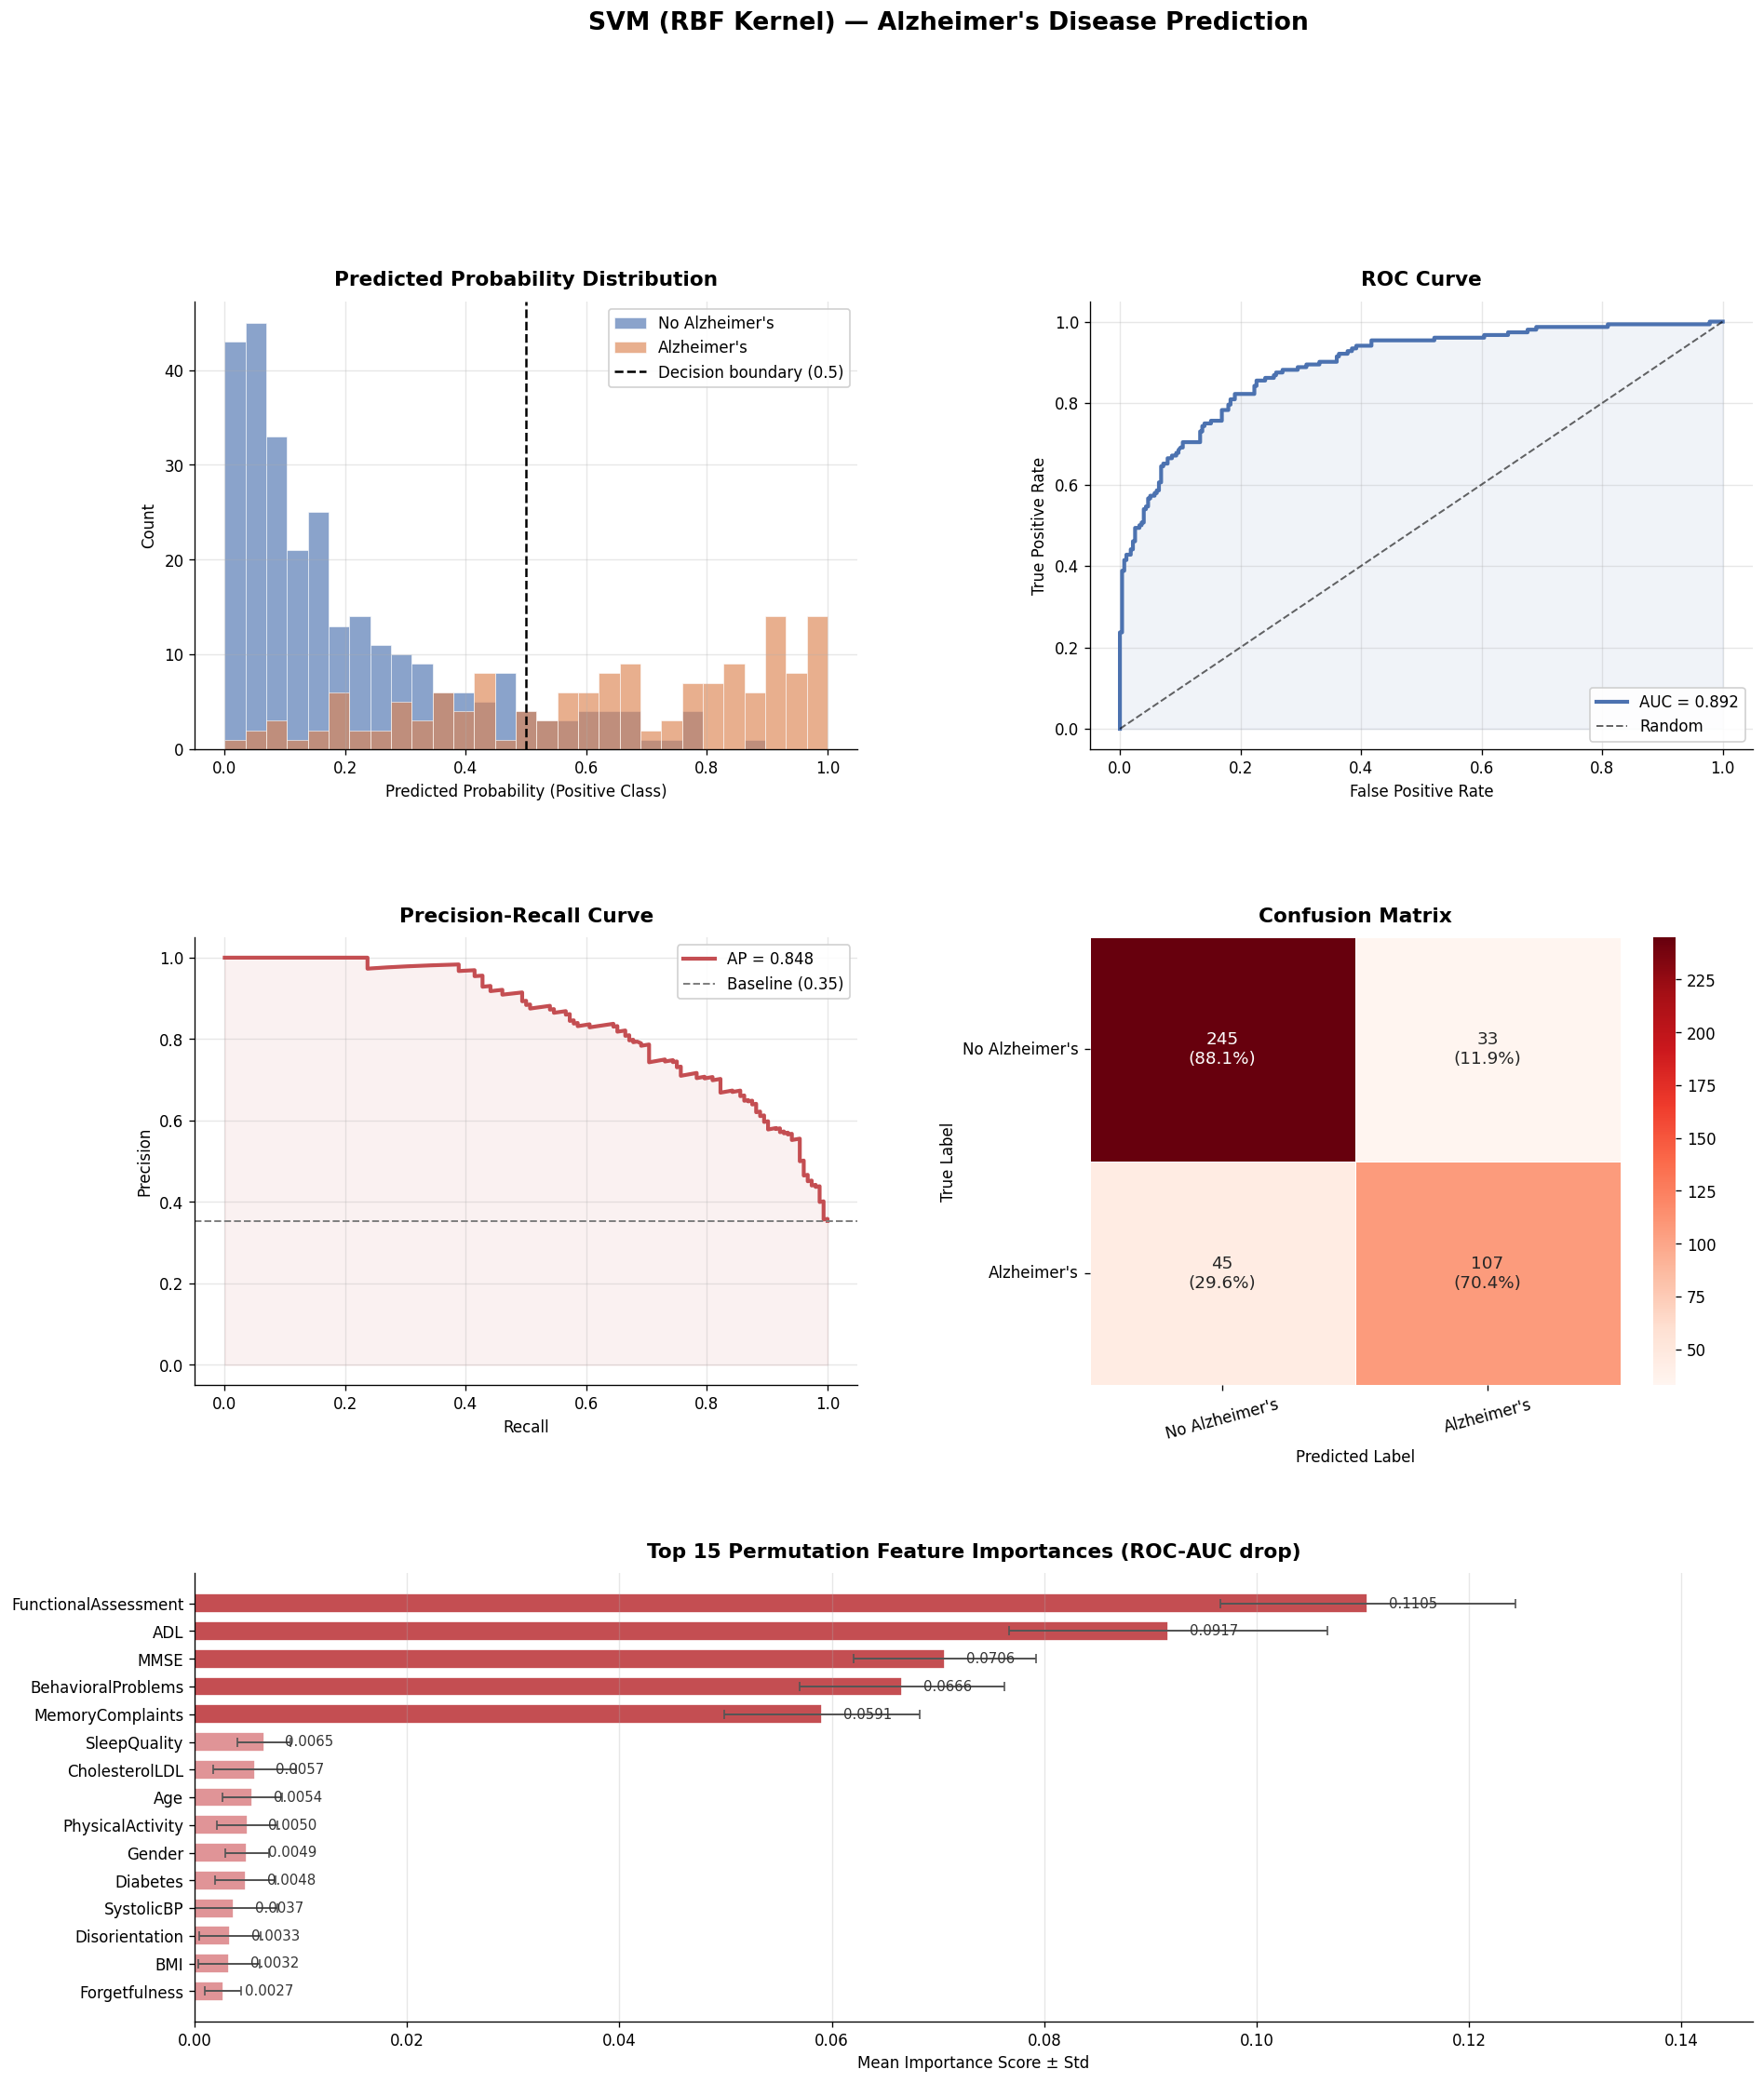

Evaluation graphs saved ✓


In [5]:

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc                  = roc_auc_score(y_test, y_proba)
precision, recall, _     = precision_recall_curve(y_test, y_proba)
avg_precision            = average_precision_score(y_test, y_proba)
cm                       = confusion_matrix(y_test, y_pred)

# Permutation importance (model-agnostic, works for any estimator)
print("Computing permutation importances (this may take a moment)...")
perm = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=20, random_state=42, scoring='roc_auc', n_jobs=-1
)
feat_imp = pd.DataFrame({
    'importance': perm.importances_mean,
    'std': perm.importances_std
}, index=X.columns).sort_values('importance', ascending=False).head(15)

# Decision scores for probability distribution plot
pos_proba = y_proba[y_test == 1]
neg_proba = y_proba[y_test == 0]

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── 1. Predicted Probability Distribution ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 30)
ax1.hist(neg_proba, bins=bins, alpha=0.65, color='#4C72B0',
         label="No Alzheimer's", edgecolor='white', linewidth=0.5)
ax1.hist(pos_proba, bins=bins, alpha=0.65, color='#DD8452',
         label="Alzheimer's",    edgecolor='white', linewidth=0.5)
ax1.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Decision boundary (0.5)')
ax1.set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Predicted Probability (Positive Class)')
ax1.set_ylabel('Count')
ax1.legend(framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# ── 2. ROC Curve ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color='#4C72B0', lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', framealpha=0.9)
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# ── 3. Precision-Recall Curve ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(recall, precision, color='#C44E52', lw=2.5, label=f'AP = {avg_precision:.3f}')
ax3.fill_between(recall, precision, alpha=0.08, color='#C44E52')
baseline = y_test.mean()
ax3.axhline(baseline, color='gray', lw=1.2, linestyle='--',
            label=f'Baseline ({baseline:.2f})')
ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(framealpha=0.9)
ax3.grid(alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)

# ── 4. Confusion Matrix ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
labels  = ["No Alzheimer's", "Alzheimer's"]
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1%})" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annots, fmt='', cmap='Reds', ax=ax4,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', cbar=True,
            annot_kws={'fontsize': 11})
ax4.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.tick_params(axis='x', rotation=15)
ax4.tick_params(axis='y', rotation=0)

# ── 5. Permutation Feature Importances ────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
colors = ['#C44E52' if i < 5 else '#E09497' for i in range(len(feat_imp))]
bars = ax5.barh(feat_imp.index[::-1], feat_imp['importance'][::-1],
                xerr=feat_imp['std'][::-1],
                color=colors[::-1], edgecolor='white', height=0.7,
                error_kw=dict(ecolor='#555', capsize=3, lw=1.2))
for bar, val in zip(bars, feat_imp['importance'][::-1]):
    ax5.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='#333')
ax5.set_title('Top 15 Permutation Feature Importances (ROC-AUC drop)', fontsize=13, fontweight='bold', pad=10)
ax5.set_xlabel('Mean Importance Score ± Std')
ax5.grid(axis='x', alpha=0.3)
ax5.spines[['top', 'right']].set_visible(False)
ax5.set_xlim(0, (feat_imp['importance'] + feat_imp['std']).max() * 1.18)

fig.suptitle("SVM (RBF Kernel) — Alzheimer's Disease Prediction", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('svm_evaluation_graphs.png', bbox_inches='tight', dpi=150)
plt.show()
print("Evaluation graphs saved ✓")


## 5. Cross-Validation Summary

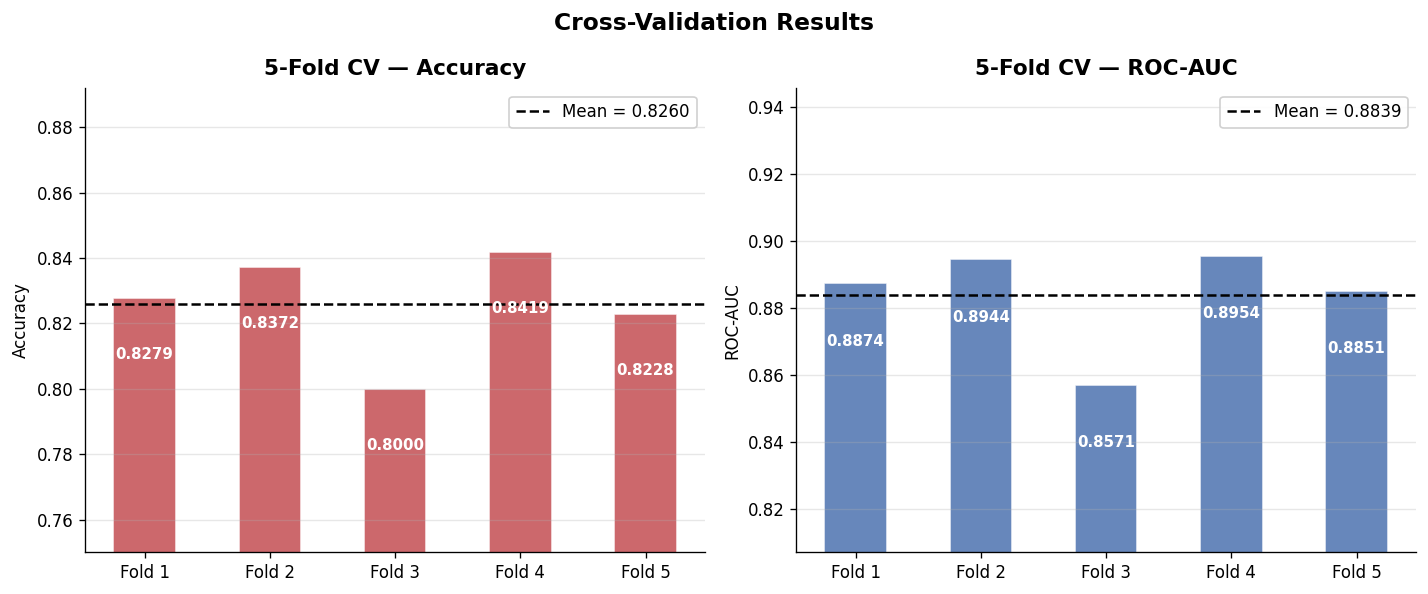

CV Accuracy : 0.8260 ± 0.0146
CV ROC-AUC  : 0.8839 ± 0.0140


In [6]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced', probability=True, random_state=42
    ))
])

acc_scores = cross_val_score(cv_pipeline, X, y, cv=cv, scoring='accuracy')
auc_scores = cross_val_score(cv_pipeline, X, y, cv=cv, scoring='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, metric, color in zip(
        axes, [acc_scores, auc_scores],
        ['Accuracy', 'ROC-AUC'], ['#C44E52', '#4C72B0']):
    folds = [f'Fold {i+1}' for i in range(len(scores))]
    bars  = ax.bar(folds, scores, color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(scores.mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean = {scores.mean():.4f}')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, val - 0.015,
                f'{val:.4f}', ha='center', va='top', fontsize=9,
                color='white', fontweight='bold')
    ax.set_title(f'5-Fold CV — {metric}', fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, scores.min() - 0.05), min(1, scores.max() + 0.05))
    ax.legend(framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Cross-Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_cv_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"CV Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"CV ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
